Week 17 · Day 5 — Diffusion Models (DDPM Intuition)
Why this matters

Diffusion models power the most realistic image generators today (e.g., DALL·E 3, Stable Diffusion).
They learn to reverse a gradual noising process — starting from pure noise and denoising step by step until a coherent image emerges.

Theory Essentials

Forward process: gradually adds Gaussian noise to data over T steps → ends in pure noise.

Reverse process: learns to denoise — predicting noise at each step to reconstruct the original image.

Score function: model estimates ∇log p(x) — the gradient toward higher data density (a “score”).

Training target: predict the noise added at each timestep.

Sampling: start from noise and apply the learned denoising T times.

Think of it as teaching the model: “Given a noisy picture, what clean image could have produced it?”


### 🌀 The Big Picture

Diffusion models are **probabilistic generative models** that learn to **reverse a gradual noising process**.

They start with a clean image (x_0) and add Gaussian noise step by step until it becomes **pure noise**.
Then they train a model to **invert** that process — to *denoise* random noise step by step back into a realistic image.

---

### ⚙️ Step-by-step logic

1. **Forward process (noising):**

   * You take a real image (x_0).

   * Gradually add Gaussian noise over (T) steps:
     [
     x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{1-\bar{\alpha_t}}\epsilon
     ]
     where (\bar{\alpha_t}) controls how much signal vs. noise remains.

   * After enough steps → (x_T) ≈ pure noise.

   > This process is *fixed and known*, no learning happens here.

2. **Reverse process (denoising):**

   * You train a neural network ( \epsilon_\theta(x_t, t) ) to predict the *noise* added at each step.

   * If it can predict the noise accurately, you can subtract it to move slightly toward the clean image.

   * By chaining these small denoising steps backwards from random noise → you generate a realistic image.

   > The model never directly sees the original image — it *learns* what kind of structure “undoes” the noise.

---

### 🧠 What’s actually being learned

* The model is learning the **score** (gradient of log-probability of data):
  how the data distribution curves through pixel space.
* This is why diffusion models can generate *incredibly realistic* outputs: they capture the fine structure of the image distribution.

---

### 🖼️ How this becomes “image generators”

Once trained, you can start from **random noise** and run the reverse (denoising) process → each random seed produces a different plausible image.

* **Text-to-image models (like Stable Diffusion)** add a *conditioning input* (text embeddings) so the denoising process knows *what kind of image* to form.
* Same principle: start from noise → guided denoising → coherent, conditioned image.

---

### ⚖️ Comparison to older generative models

| Model         | Key idea                                  | Pros                                | Cons                           |
| ------------- | ----------------------------------------- | ----------------------------------- | ------------------------------ |
| **VAE**       | Learn latent distribution (encode–decode) | Smooth latent space                 | Slightly blurry outputs        |
| **GAN**       | Compete G vs. D                           | Sharp, realistic samples            | Unstable, no probability model |
| **Diffusion** | Learn to reverse noise                    | Stable, high fidelity, controllable | Slow (many steps)              |

---

### 💡 In short

> Diffusion models are like **learned reverse noise simulators**:
> They know how to take random noise and iteratively *recover structure* until an image emerges.

That’s why all modern image generators — from **Stable Diffusion** to **DALL·E 3** — are built on this principle.


### 🧩 1. What the diffusion model knows after training

Once trained, a diffusion model has learned **how to turn random noise into a realistic image** —
but **not necessarily a specific image** (like “a cat”).

It knows the *distribution of all images* it was trained on — like a mental map of what “natural images” look like — edges, textures, shapes, lighting, etc.

So if you start from **pure noise** and let it denoise step by step, it will produce *some* random realistic image (a tree, a shoe, a sky — anything from its data distribution).

---

### 🧠 2. How text conditioning changes the game

To make it generate **a cat** instead of a random image, we give the model **extra information**: a *text embedding* from another neural network (like CLIP or a Transformer encoder).

* That embedding is a **vector representation of the text “a cat”** — it captures semantic meaning.
* During denoising, the model looks at both:

  * The **current noisy image** (x_t)
  * The **text embedding** (guidance)

and it adjusts its denoising so that the final image *matches what “a cat” looks like*.

---

### 🔁 3. What actually happens during generation

1. Start with **pure noise** (x_T).
2. At each timestep (t), the model predicts the noise (\hat{\epsilon}) to remove **while being guided by the text**:
   [
   x_{t-1} = f(x_t, \text{text embedding})
   ]
3. As it iterates backwards, the image gradually **emerges from the noise** — blurry shapes first, then sharper details.

So it’s not *drawing* a cat from scratch — it’s **selectively denoising** the random noise so that what remains fits the concept “cat.”

---

### 🎨 4. Analogy

Think of it like this:

> The model starts with a cloud of static noise.
> The text prompt “cat” acts like a **magnetic field** that pulls the denoising process toward regions of noise that look like cats.

Over many steps, structure forms: fuzzy ears → whiskers → full cat.

---

### 🧭 5. The “guidance” signal

In models like **Stable Diffusion**, this is called **classifier-free guidance**:

* The model learns to denoise both *with* and *without* text conditioning.
* During generation, it amplifies the “with-text” version slightly — steering the output more strongly toward the prompt.

That’s how you can “dial up” how literally the model follows your words.

---

### 🧠 Summary

| Step                 | What happens                                                |
| -------------------- | ----------------------------------------------------------- |
| 1️⃣ Train            | Model learns to denoise random noise into realistic images. |
| 2️⃣ Add text encoder | Each prompt becomes a numerical guide.                      |
| 3️⃣ Generate         | Start from noise → iteratively denoise → guided by text.    |
| 4️⃣ Output           | A clean image that aligns with the prompt (“a cat”).        |

---

So yes — you’re absolutely right:

> Diffusion models don’t *draw*; they *sculpt* order out of noise — and the text prompt tells them **what kind of order** to aim for.


Step 0: loss=1.0103
Step 400: loss=1.2038
Step 800: loss=0.9594
Step 1200: loss=0.7922
Step 1600: loss=0.9277


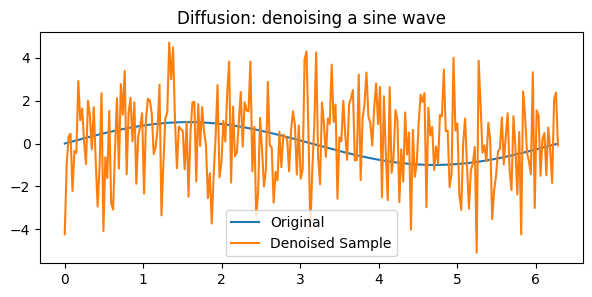

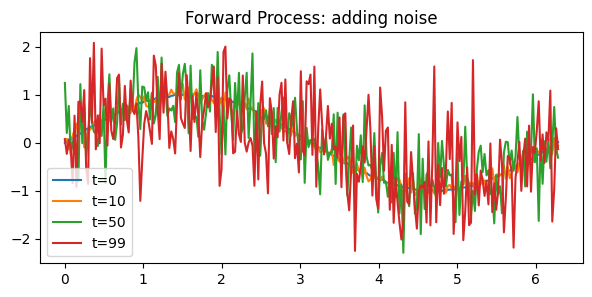

In [2]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Create clean data (sin waves) ---
n = 256
x = torch.linspace(0, 2 * torch.pi, n)
clean = torch.sin(x).unsqueeze(0)

# --- Add noise (forward process) ---
T = 100  # number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def add_noise(x0, t):
    noise = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t]
    noisy = (alpha_bar_t**0.5) * x0 + (1 - alpha_bar_t)**0.5 * noise
    return noisy, noise

# --- Simple denoiser (tiny MLP) ---
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n + 1, 256), nn.ReLU(),
            nn.Linear(256, n)
        )
    def forward(self, xt, t):
        xt = xt.view(xt.size(0), -1)
        # scalar time feature in [0,1]
        t_embed = t.float().unsqueeze(1) / T           # [batch, 1]
        inp = torch.cat([xt, t_embed], dim=1)          # [batch, n+1] = [1, 257]
        return self.net(inp)

        
model = Denoiser().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- Training ---
epochs = 2000
for step in range(epochs):
    t = torch.randint(0, T, (1,))
    xt, noise = add_noise(clean, t)
    pred_noise = model(xt.to(device), t.to(device))
    loss = loss_fn(pred_noise, noise.to(device))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 400 == 0:
        print(f"Step {step}: loss={loss.item():.4f}")

# --- Sampling (reverse process) ---
with torch.no_grad():
    x_t = torch.randn_like(clean).to(device)
    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device)
        noise_pred = model(x_t, t_tensor)
        alpha = alphas[t]; alpha_bar = alpha_bars[t]
        beta = betas[t]
        mean = (1 / alpha**0.5) * (x_t - (1 - alpha) / (1 - alpha_bar)**0.5 * noise_pred)
        x_t = mean + beta**0.5 * torch.randn_like(x_t) if t > 0 else mean
    denoised = x_t.cpu().squeeze()

# --- Visualize ---
plt.figure(figsize=(7,3))
plt.plot(x, clean.squeeze(), label="Original")
plt.plot(x, denoised, label="Denoised Sample")
plt.legend(); plt.title("Diffusion: denoising a sine wave"); plt.show()

# Visualize progressive noising
plt.figure(figsize=(7,3))
for step in [0, 10, 50, 99]:
    noisy, _ = add_noise(clean, torch.tensor(step))
    plt.plot(x, noisy.squeeze(), label=f"t={step}")
plt.legend(); plt.title("Forward Process: adding noise"); plt.show()


1) Core (10 min)
Task: Plot the noisy sine waves for t = 0, 25, 50, 99.

AS t increases the signal disappears into gaussian noise. Denoised result still has a lot of noise.

2) Practice (15 min)
Task: Increase T to 200 and re-run.
Hint: More steps = smoother but slower denoising.

Step 0: loss=1.0105
Step 400: loss=1.1726
Step 800: loss=0.8252
Step 1200: loss=0.7458
Step 1600: loss=0.9488


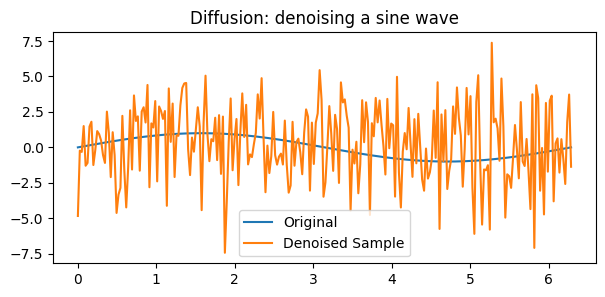

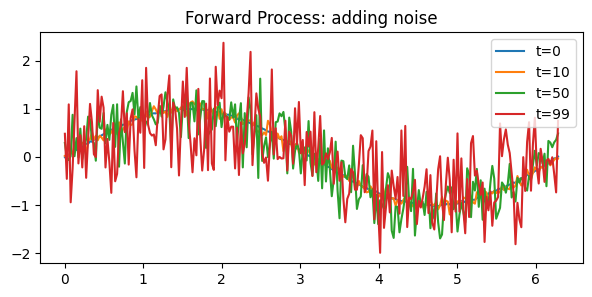

In [3]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Create clean data (sin waves) ---
n = 256
x = torch.linspace(0, 2 * torch.pi, n)
clean = torch.sin(x).unsqueeze(0)

# --- Add noise (forward process) ---
T = 200  # number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def add_noise(x0, t):
    noise = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t]
    noisy = (alpha_bar_t**0.5) * x0 + (1 - alpha_bar_t)**0.5 * noise
    return noisy, noise

# --- Simple denoiser (tiny MLP) ---
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n + 1, 256), nn.ReLU(),
            nn.Linear(256, n)
        )
    def forward(self, xt, t):
        xt = xt.view(xt.size(0), -1)
        # scalar time feature in [0,1]
        t_embed = t.float().unsqueeze(1) / T           # [batch, 1]
        inp = torch.cat([xt, t_embed], dim=1)          # [batch, n+1] = [1, 257]
        return self.net(inp)

        
model = Denoiser().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- Training ---
epochs = 2000
for step in range(epochs):
    t = torch.randint(0, T, (1,))
    xt, noise = add_noise(clean, t)
    pred_noise = model(xt.to(device), t.to(device))
    loss = loss_fn(pred_noise, noise.to(device))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 400 == 0:
        print(f"Step {step}: loss={loss.item():.4f}")

# --- Sampling (reverse process) ---
with torch.no_grad():
    x_t = torch.randn_like(clean).to(device)
    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device)
        noise_pred = model(x_t, t_tensor)
        alpha = alphas[t]; alpha_bar = alpha_bars[t]
        beta = betas[t]
        mean = (1 / alpha**0.5) * (x_t - (1 - alpha) / (1 - alpha_bar)**0.5 * noise_pred)
        x_t = mean + beta**0.5 * torch.randn_like(x_t) if t > 0 else mean
    denoised = x_t.cpu().squeeze()

# --- Visualize ---
plt.figure(figsize=(7,3))
plt.plot(x, clean.squeeze(), label="Original")
plt.plot(x, denoised, label="Denoised Sample")
plt.legend(); plt.title("Diffusion: denoising a sine wave"); plt.show()

# Visualize progressive noising
plt.figure(figsize=(7,3))
for step in [0, 10, 50, 99]:
    noisy, _ = add_noise(clean, torch.tensor(step))
    plt.plot(x, noisy.squeeze(), label=f"t={step}")
plt.legend(); plt.title("Forward Process: adding noise"); plt.show()


Slightly less noise in denoised sample

3) Stretch (optional)
Task: Try a cosine instead of sine wave as target.
Hint: Just replace torch.sin(x) → torch.cos(x) in data.

Step 0: loss=0.9861
Step 400: loss=1.1956
Step 800: loss=0.9676
Step 1200: loss=0.8099
Step 1600: loss=0.9355


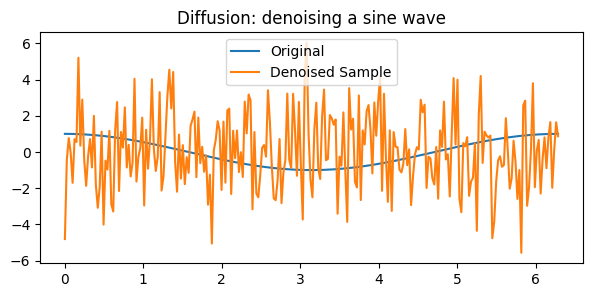

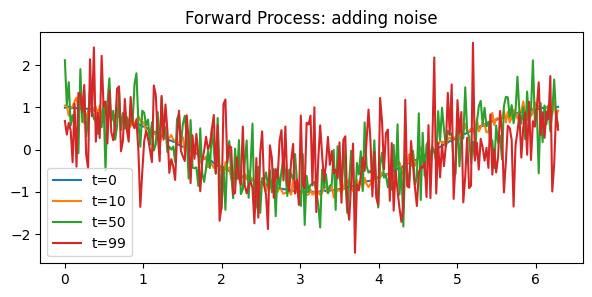

In [4]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Create clean data (cos waves) ---
n = 256
x = torch.linspace(0, 2 * torch.pi, n)
clean = torch.cos(x).unsqueeze(0)

# --- Add noise (forward process) ---
T = 100  # number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def add_noise(x0, t):
    noise = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t]
    noisy = (alpha_bar_t**0.5) * x0 + (1 - alpha_bar_t)**0.5 * noise
    return noisy, noise

# --- Simple denoiser (tiny MLP) ---
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n + 1, 256), nn.ReLU(),
            nn.Linear(256, n)
        )
    def forward(self, xt, t):
        xt = xt.view(xt.size(0), -1)
        # scalar time feature in [0,1]
        t_embed = t.float().unsqueeze(1) / T           # [batch, 1]
        inp = torch.cat([xt, t_embed], dim=1)          # [batch, n+1] = [1, 257]
        return self.net(inp)

        
model = Denoiser().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- Training ---
epochs = 2000
for step in range(epochs):
    t = torch.randint(0, T, (1,))
    xt, noise = add_noise(clean, t)
    pred_noise = model(xt.to(device), t.to(device))
    loss = loss_fn(pred_noise, noise.to(device))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 400 == 0:
        print(f"Step {step}: loss={loss.item():.4f}")

# --- Sampling (reverse process) ---
with torch.no_grad():
    x_t = torch.randn_like(clean).to(device)
    for t in reversed(range(T)):
        t_tensor = torch.tensor([t], device=device)
        noise_pred = model(x_t, t_tensor)
        alpha = alphas[t]; alpha_bar = alpha_bars[t]
        beta = betas[t]
        mean = (1 / alpha**0.5) * (x_t - (1 - alpha) / (1 - alpha_bar)**0.5 * noise_pred)
        x_t = mean + beta**0.5 * torch.randn_like(x_t) if t > 0 else mean
    denoised = x_t.cpu().squeeze()

# --- Visualize ---
plt.figure(figsize=(7,3))
plt.plot(x, clean.squeeze(), label="Original")
plt.plot(x, denoised, label="Denoised Sample")
plt.legend(); plt.title("Diffusion: denoising a sine wave"); plt.show()

# Visualize progressive noising
plt.figure(figsize=(7,3))
for step in [0, 10, 50, 99]:
    noisy, _ = add_noise(clean, torch.tensor(step))
    plt.plot(x, noisy.squeeze(), label=f"t={step}")
plt.legend(); plt.title("Forward Process: adding noise"); plt.show()


Mini-Challenge (≤40 min)

Goal: Animate the reverse diffusion steps to visualize generation.
Acceptance Criteria:

Start from random noise → gradually denoise into a sine wave.

Save or display an animation (e.g. matplotlib.animation.FuncAnimation).

Short comment explaining how the model "learns to reverse noise."

step 600/6000  loss=0.4591
step 1200/6000  loss=0.2957
step 1800/6000  loss=0.2482
step 2400/6000  loss=0.2399
step 3000/6000  loss=0.2144
step 3600/6000  loss=0.2069
step 4200/6000  loss=0.2188
step 4800/6000  loss=0.2278
step 5400/6000  loss=0.2082
step 6000/6000  loss=0.2073


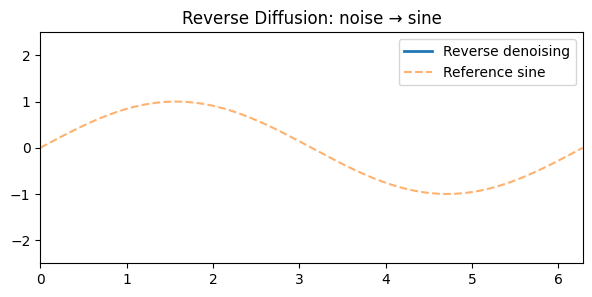

Saved animation to: animations/reverse_diffusion.gif

Comment:
The denoiser learns to predict the Gaussian noise added at each timestep (εθ(x_t, t)).
During sampling we subtract that predicted noise step-by-step, moving x_t slightly
toward higher-probability (structured) signals; chaining all steps sculpts noise into a sine wave.


In [5]:
# === Mini-Challenge: Animate reverse diffusion on a sine wave ===
import math, os
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------- Data (1D signals) --------------------------
n = 256                                   # points on the x-axis
x = torch.linspace(0, 2*math.pi, n)       # [n]

def sample_clean_batch(bs):
    """
    Generate a mini-batch of sine waves with random amplitude/phase/frequency.
    This makes learning denoising much easier than a single example.
    """
    amp  = torch.empty(bs).uniform_(0.8, 1.2)
    freq = torch.empty(bs).uniform_(0.9, 1.1)          # small freq jitter
    phase= torch.empty(bs).uniform_(0, 2*math.pi)
    waves = torch.stack([amp[i]*torch.sin(freq[i]*x + phase[i]) for i in range(bs)], dim=0)
    return waves                                       # [bs, n]

# -------------------------- Diffusion schedule --------------------------
T = 100
betas = torch.linspace(1e-4, 0.02, T, device=device)   # linear beta schedule
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)              # \bar{α}_t

def add_noise(x0, t):
    """
    Forward noising: q(x_t | x_0) = N( sqrt(alpha_bar_t)*x0, (1-alpha_bar_t) I )
    x0: [bs, n], t: [bs] or scalar
    """
    bs = x0.size(0)
    eps = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t].view(bs, 1)            # broadcast to [bs,1]
    xt = torch.sqrt(alpha_bar_t)*x0 + torch.sqrt(1 - alpha_bar_t)*eps
    return xt, eps

# -------------------------- Tiny denoiser --------------------------
class Denoiser(nn.Module):
    def __init__(self, signal_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(signal_len + 1, 256), nn.ReLU(),
            nn.Linear(256, signal_len)
        )
    def forward(self, xt, t):
        # xt: [bs, n]; t: [bs] (ints)
        xt = xt.view(xt.size(0), -1)
        t_feat = (t.float()/T).unsqueeze(1)            # scalar time in [0,1]
        inp = torch.cat([xt, t_feat], dim=1)           # [bs, n+1]
        return self.net(inp)

model = Denoiser(n).to(device)
opt = optim.Adam(model.parameters(), lr=5e-4)
mse = nn.MSELoss()

# -------------------------- Train (few thousand iters) --------------------------
steps = 6000              # ~a couple minutes on CPU; increase if results are too noisy
bs    = 64

for step in range(1, steps+1):
    x0 = sample_clean_batch(bs).to(device)
    t  = torch.randint(0, T, (bs,), device=device)     # one timestep per example
    xt, eps = add_noise(x0, t)
    pred_eps = model(xt, t)
    loss = mse(pred_eps, eps)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 600 == 0:
        print(f"step {step}/{steps}  loss={loss.item():.4f}")

# -------------------------- Reverse process + animation --------------------------
# Start from pure noise and iteratively denoise.
with torch.no_grad():
    frames = []
    x_t = torch.randn(1, n, device=device)             # start from noise (batch=1)
    frames.append(x_t.squeeze().cpu())

    for t in reversed(range(T)):
        t_batch = torch.tensor([t], device=device)
        eps_pred = model(x_t, t_batch)                 # predict noise at step t

        a  = alphas[t]
        ab = alpha_bars[t]
        # DDPM mean update:
        mean = (1/torch.sqrt(a)) * (x_t - (1-a)/torch.sqrt(1-ab) * eps_pred)
        if t > 0:
            z = torch.randn_like(x_t)
            x_t = mean + torch.sqrt(betas[t]) * z
        else:
            x_t = mean
        # Save a handful of frames (all steps = smooth animation)
        frames.append(x_t.squeeze().cpu())

# -------------------------- Build & display/save animation --------------------------
fig, ax = plt.subplots(figsize=(7,3))
line, = ax.plot([], [], lw=2, label="Reverse denoising")
ax.plot(x, torch.sin(x).cpu(), '--', alpha=0.6, label="Reference sine")
ax.set_xlim(x.min().item(), x.max().item())
ax.set_ylim(-2.5, 2.5)
ax.set_title("Reverse Diffusion: noise → sine")
ax.legend()

def init():
    line.set_data([], [])
    return (line,)

def update(i):
    y = frames[i]
    line.set_data(x, y)
    ax.set_title(f"Reverse Diffusion (step {i}/{len(frames)-1})")
    return (line,)

anim = FuncAnimation(fig, update, init_func=init,
                     frames=len(frames), interval=60, blit=True)
plt.show()

# Save as GIF (works without ffmpeg)
os.makedirs("animations", exist_ok=True)
gif_path = "animations/reverse_diffusion.gif"
anim.save(gif_path, writer=PillowWriter(fps=20))
print(f"Saved animation to: {gif_path}")

# -------------------------- Short comment --------------------------
print("\nComment:")
print("The denoiser learns to predict the Gaussian noise added at each timestep (εθ(x_t, t)).")
print("During sampling we subtract that predicted noise step-by-step, moving x_t slightly")
print("toward higher-probability (structured) signals; chaining all steps sculpts noise into a sine wave.")


Notes / Key Takeaways

Diffusion models learn to predict noise, not pixels.

Generation = iterative denoising → high realism, stability.

They connect to score matching and energy-based models.

Unlike GANs, they’re stable to train but computationally heavy.

Forward process: simple → Reverse process: learned.

Reflection

Why does training a diffusion model require learning noise instead of data directly?

What happens if the model predicts noise incorrectly early in the reverse process?

1. Why does training a diffusion model require learning noise instead of data directly?
Because at each step the data is mostly noise — the model can’t see the original signal clearly.
Predicting the added noise is simpler and more stable: if the model learns what noise looks like, it can subtract it to recover the clean signal.
This makes training mathematically well-behaved and equivalent to maximizing data likelihood.

2. What happens if the model predicts noise incorrectly early in the reverse process?
Early errors amplify through later steps: the model starts denoising from wrong intermediate states, causing the final image (or signal) to drift, blur, or collapse into unrealistic patterns.
Accurate noise prediction in the first few steps is critical because each later step builds on those corrections.


### 🧩 1. Yes — there **is** a real sine wave during training

During training, we *do* know the **clean signal** (the ground-truth sine wave).
That’s how the model learns what’s “signal” and what’s “noise.”

Think of it like this:

* You start with a clean sine wave (x_0).
* You add known Gaussian noise to get (x_t).
* You also **keep track** of the exact random noise (\varepsilon) you added.
* The model’s job is to **predict that exact noise** given (x_t) and (t).

So yes — at training time, there’s always supervision:

```python
loss = MSE(predicted_noise, true_noise)
```

The “true noise” is the ground-truth target.

That’s how the model learns what kind of noise was added — by comparing its prediction with the actual random noise it saw during the forward process.

---

### 🧠 2. Over many examples, it learns patterns of “what’s likely signal”

At first, the model can’t tell what’s sine and what’s random jitter.
But after seeing **thousands of examples** of sine waves with different random noise, it starts recognizing *consistent structure* (the smooth curve) versus *random fluctuations* (the noise).

It realizes:

> “Every time I see this kind of smooth oscillation under the noise, that’s the part that stays the same. The random stuff changes every time — that must be noise.”

That’s why we train on *many* noisy versions — the sine pattern stays consistent, the noise doesn’t.

---

### ⚙️ 3. What happens at generation time

Now, when you *generate*, you **don’t have the real sine wave anymore** — you start from pure noise.
But because the model learned how to *remove noise step by step* during training, it can now **apply that knowledge in reverse**:

> “If this were a real noisy sine, the underlying pattern would probably look like this…”

So it keeps subtracting the noise patterns it has learned, gradually sculpting a smooth sine.

---

### 🎨 4. Analogy

Imagine you teach someone how to clean a blurry picture:

* During training, you show them the **original clean photo** and many **noisy versions**.
* They learn what’s “true detail” and what’s “random dust.”
* Later, you give them a totally new noisy picture — they’ve never seen the clean version, but they’ve learned *how* to clean.

That’s diffusion training: supervised learning of **“what noise looks like”** so the model can later **remove it without needing the ground truth.**

---

### ✅ TL;DR

* During training, the model **is supervised** — it knows both the noisy signal and the clean signal (via the true noise vector).
* It learns to predict the noise that was added.
* Over many examples, it generalizes what “real structure” looks like.
* At generation time, it applies that knowledge to sculpt order out of pure noise — no ground truth needed then.
